## Student Performance Indicator

# Life Cycle of Machine Learning Projects

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform 
- Exploratory data analysis
- Data Pre-Processing 
- Model Training 
- Choose best model


## 1) Problem Statement

- The project understand how the students performance (test scores) is affected by other variable such as Gender,Ethnicity,Parental Level of Education, Lunch and Test preparation course


## 2) Data Collection

- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consist of 8 column and 1000 rows

## 2.1 Import data and Required Packages

Importing Pandas,Numpy,Matplotlib,Seaborn and Warning Library

In [27]:
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
%matplotlib inline 
import warnings
warnings.filterwarnings('ignore')

Import the CSV Data as Pandas DataFrame

In [28]:
data = pd.read_csv('Data/Stud.csv')

# Show Top 5 Records

In [29]:
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Shape of Dataset

In [30]:
data.shape

(1000, 8)

## 2.2 Dataset Information

- gender: sex of students->(Male/female)
- race/ethnicity: ethnicity of students->(Group A,B,C,D) 
- parental level of Education: parents'finaleducation->(bachelor's degree,some college,master's degree,associate's degree,high School)
- lunch: having lunch before test(Standard or Free/reduced)
- test preparation course: complete or not complete before test
- math score
- reading score
- writing score

## 3. Data Checking to perform 

- check Missing values 
- check Duplicates
- check data types 
- check the numbers of unique value of each column
- check the statistics of data set
- check the various categories present in the different categorical column

# 3.1 Check Missing values

In [31]:
data.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

There are no missing values in the data set

# 3.2 check Duplicates

In [32]:
data.duplicated().sum()

np.int64(0)

there are no duplicates in the dataset

# 3.3 Check data types

In [33]:
# check Null and Dtypes
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


# 3.4 checking the number of unique values of each columns

In [34]:
data.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

# 3.5 check statistic of dataset

In [35]:
data.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


-- Insight

- From above description of numeric data, all means are very close to each other --between 66 and 68.05
- All standard deviation are also close - between 14.6 and 15.19
- while there is minimum score 0 for math ,for writing is much higher = 10 and for reading might higher = 17

## 3.7 Exploring Data

In [36]:
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [37]:
print("the categorical data of the 'gender' Variable is: ",end='')
print(data['gender'].unique())

print("the categorical data of the 'race/ethnicity' variable is: ",end='')
print(data['race/ethnicity'].unique())

print("the categorical data of the 'parental level of education' variable is: ",end='')
print(data['parental level of education'].unique())

print("the categorical data of the 'Lunch' variable is: ",end='')
print(data['lunch'].unique())

print("the categorical data of the 'test preparation course' variable is: ",end='')
print(data['test preparation course'].unique())


the categorical data of the 'gender' Variable is: <StringArray>
['female', 'male']
Length: 2, dtype: str
the categorical data of the 'race/ethnicity' variable is: <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
the categorical data of the 'parental level of education' variable is: <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
the categorical data of the 'Lunch' variable is: <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
the categorical data of the 'test preparation course' variable is: <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [38]:
# define the numerical and categorical columns
numerical_cols = [feature for feature in data.columns if data[feature].dtype != 'O']
categorical_cols = [features for features in data.columns if data[features].dtypes == 'O']

## print columns 
print("we have {} nummerical columns: {}".format(len(numerical_cols),numerical_cols))
print("we have {} categorical columns: {}".format(len(categorical_cols),categorical_cols))

we have 8 nummerical columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']
we have 0 categorical columns: []


In [39]:
data.head(2)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


## 3.8 Adding columns for "Total Score" and "Average"

In [40]:
data['total score'] = data['math score'] + data['reading score'] + data['writing score']
data['average'] = data['total score']/3
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [41]:
reading_full = data[data['reading score'] == 100]['average'].count()
writing_full = data[data['writing score'] == 100]['average'].count()
math_full = data[data['math score'] == 100]['average'].count()

print("the Number of students who get full marks in reading is: ",reading_full)
print("the Number of students who get full marks in writing is: ",writing_full)
print("the Number of students who get full marks in math is: ",math_full)

the Number of students who get full marks in reading is:  17
the Number of students who get full marks in writing is:  14
the Number of students who get full marks in math is:  7


In [42]:
reading_min = data[data['reading score'] <= 20]['average'].count()
writing_min = data[data['writing score'] <= 20]['average'].count()
math_min = data[data['math score'] <= 20]['average'].count()


print("the number of student who get minimum marks in reading is: ",reading_min)
print("the number of student who get minimum marks in writing is: ",writing_min)
print("the number of student who get minimum marks in math is: ",math_min)

the number of student who get minimum marks in reading is:  1
the number of student who get minimum marks in writing is:  3
the number of student who get minimum marks in math is:  4


Insights

- from above value who get students have performed the worst in the math
- Best performance in the reading section

# 4. Explorating Data (Visualization)
###  4.1 Visualize average score distribution to make some conclusion 
- Histogram
- kernel Distribution Function (KDE)

### 4.1.1 Histogram and kde

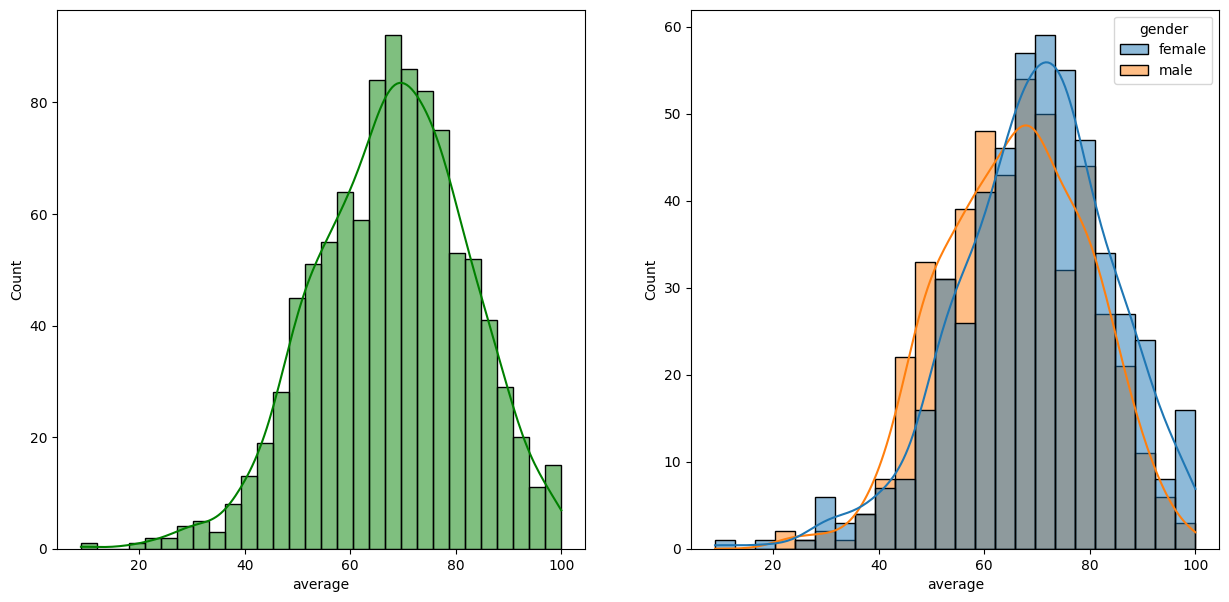

In [48]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=data, x ='average',bins=30,kde= True,color='g')
plt.subplot(122)
sns.histplot(data=data,x='average',kde=True,hue='gender')
plt.show()

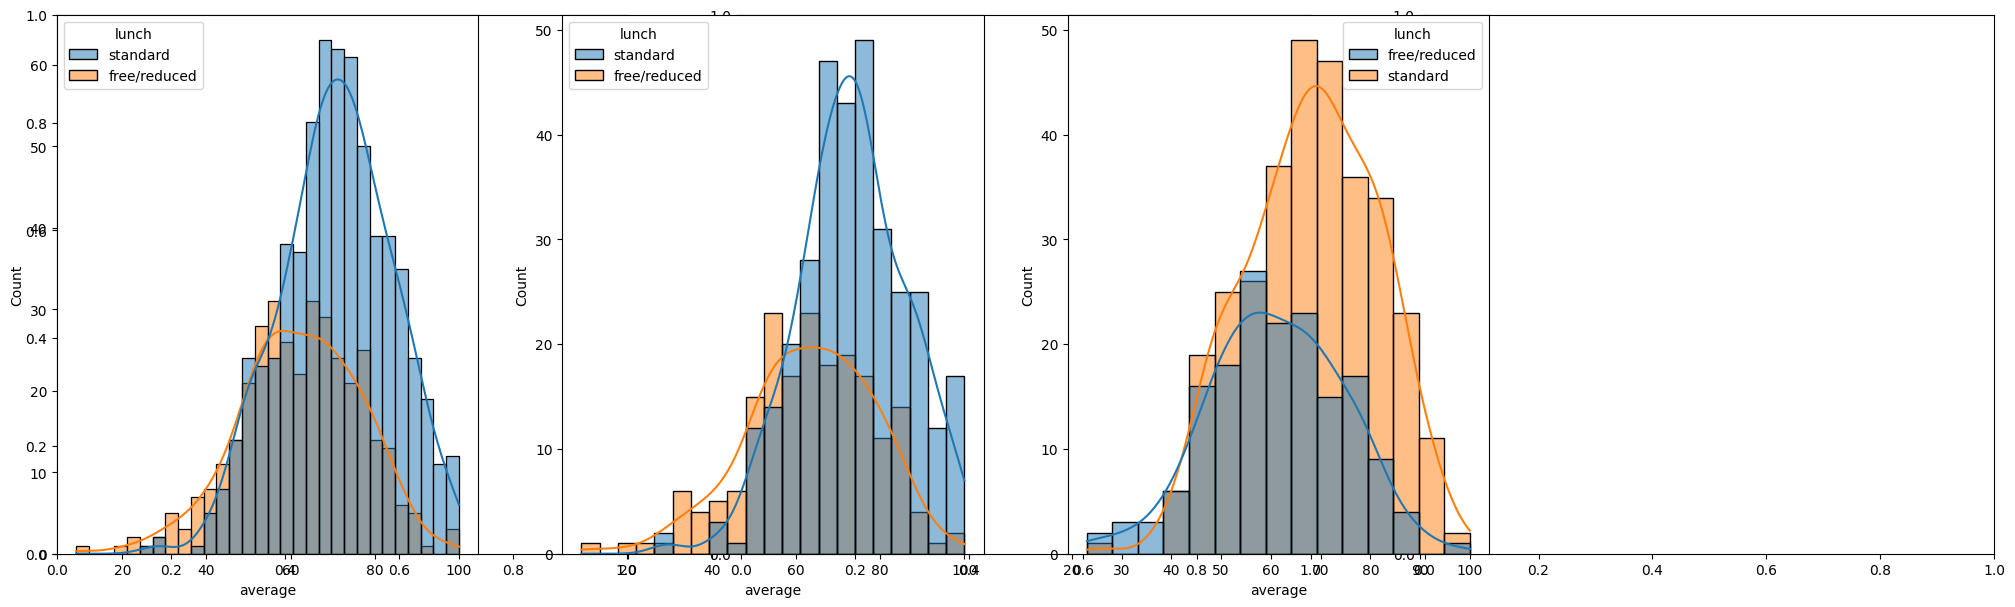

In [50]:
fig , axs = plt.subplots(1,3,figsize=(25,7))
plt.subplot(141)
sns.histplot(data=data,x='average',bins=30,kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=data[data.gender=='female'],x='average',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=data[data.gender=='male'],x='average',kde=True,hue='lunch')
plt.show()

Insights

- Standard lunch help perform well in the exam 
- Standard lunch help perform well in the exam be it male or female

In [52]:
data.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'total score', 'average'],
      dtype='str')

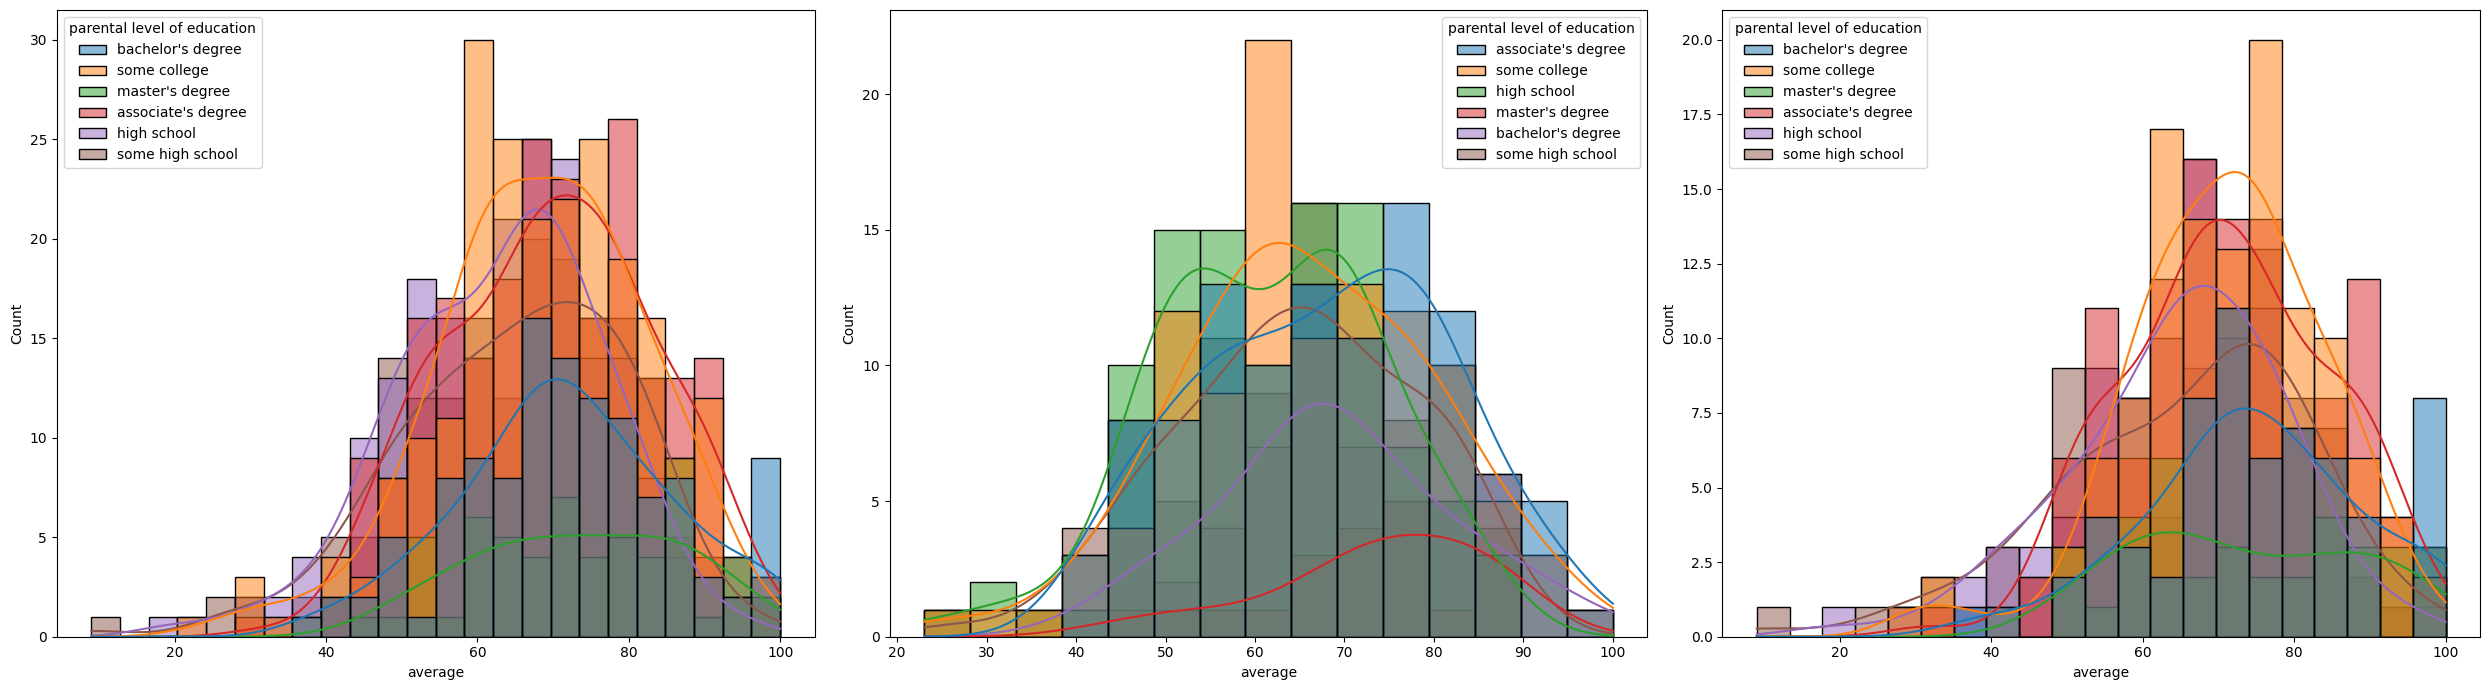

In [53]:
fig ,axs = plt.subplots(1,3,figsize=(25,7))
sns.histplot(data=data,x='average',kde=True,hue='parental level of education',ax=axs[0])
sns.histplot(data=data[data.gender=='male'],x='average',kde=True,hue='parental level of education',ax=axs[1])
sns.histplot(data=data[data.gender == 'female'],x='average',kde=True,hue='parental level of education',ax=axs[2])

plt.tight_layout()
plt.show()

Insights
- In general parent's education don't help student perform well in exam.
- 2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
- 3rd plot we can see there is no effect of parent's education on female students.
• There is a slight positive trend where students with parents having higher education (master’s, bachelor’s) tend to have higher average scores.

• For male students, this effect is more visible — higher parental education correlates with better performance.

• For female students, the distribution is more consistent across categories, indicating relatively lower dependency on parental education.

• Overall, parental education has an influence, but it is not the strongest factor affecting performance.

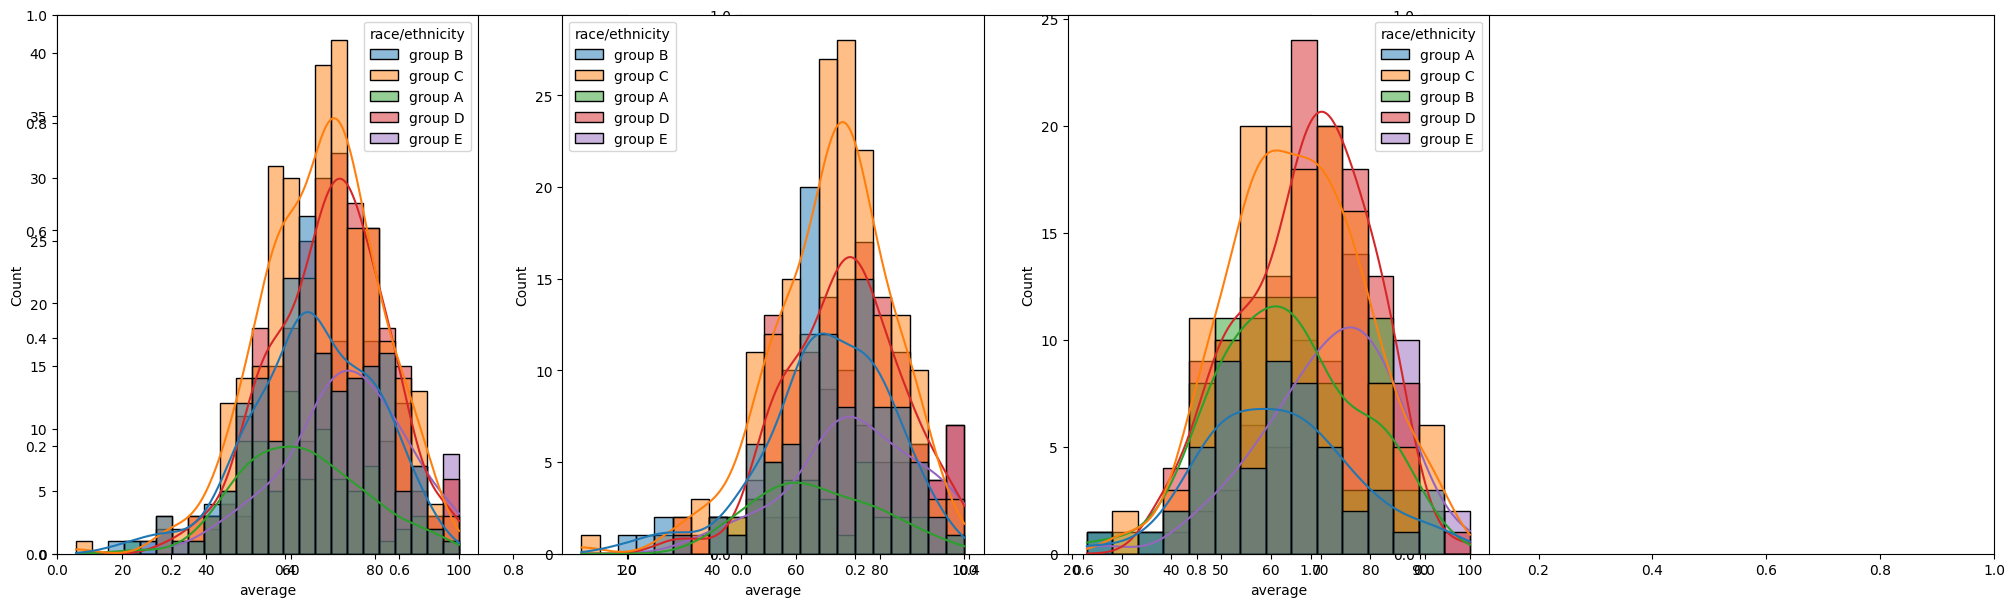

In [55]:
plt.subplots(1,3,figsize=(25,7))
plt.subplot(141)
ax = sns.histplot(data=data,x='average',kde=True,hue='race/ethnicity')
plt.subplot(142)
ax = sns.histplot(data=data[data.gender=='female'],x='average',kde=True,hue='race/ethnicity')
plt.subplot(143)
ax= sns.histplot(data=data[data.gender=='male'],x='average',kde=True,hue='race/ethnicity')
plt.show()

Insights
- Students of group A and group B tends to perform poorly in exam.
- Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female

## 4.2 Maximumum score of students in all three subjects

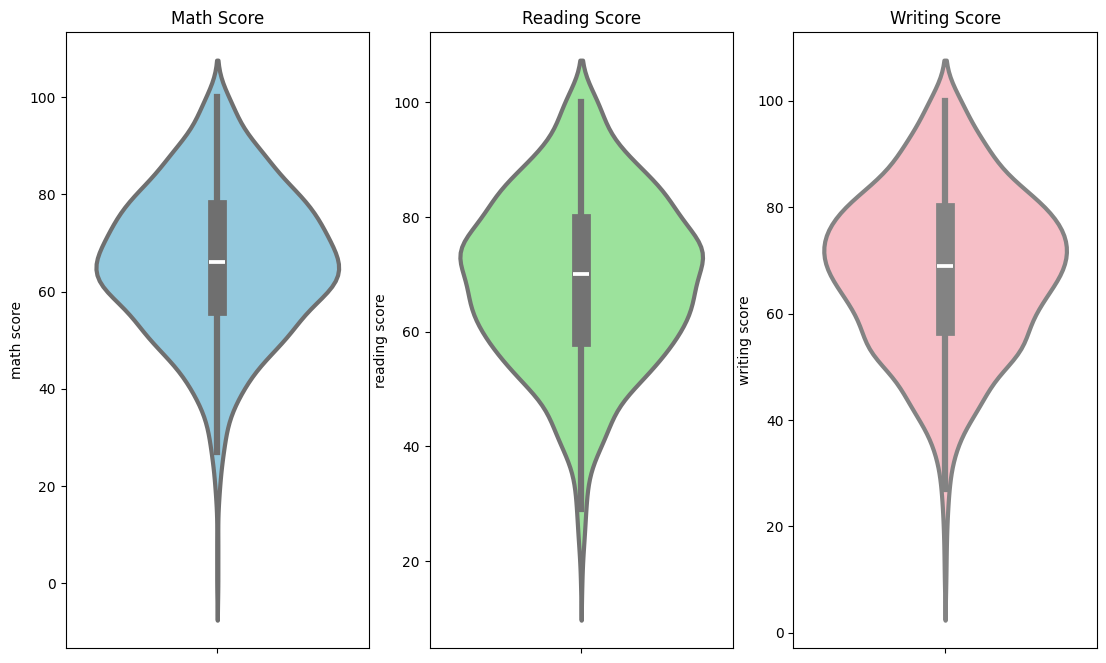

In [57]:
plt.figure(figsize=(18,8))
plt.subplot(1,4,1)
plt.title('Math Score')
sns.violinplot(y='math score',data=data,color='skyblue',linewidth=3)
plt.subplot(1,4,2)
plt.title('Reading Score')
sns.violinplot(y='reading score',data=data,color='lightgreen',linewidth=3)
plt.subplot(1,4,3)
plt.title('Writing Score')
sns.violinplot(y='writing score',data=data,color='lightpink',linewidth=3)
plt.show()

Insights
- From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80

## 4.3 Multivariate analysis using pieplot


(np.float64(-1.25), np.float64(1.25), np.float64(-1.25), np.float64(1.25))

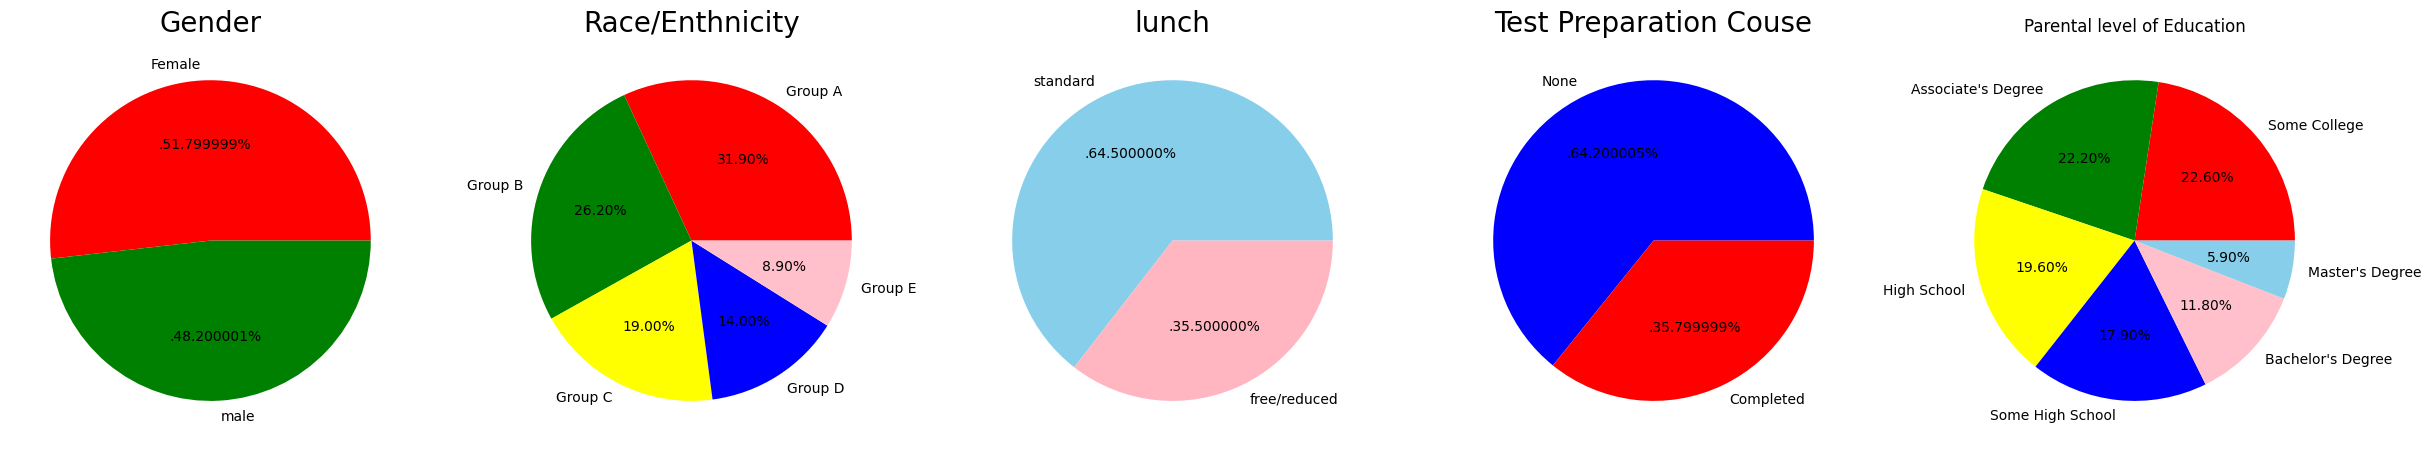

In [67]:
plt.rcParams['figure.figsize']= (30,12)

plt.subplot(1,5,1)
size = data['gender'].value_counts()
labels= 'Female','male'
color = ['red','green']

plt.pie(size,colors=color,labels = labels,autopct= '.%2f%%')
plt.title('Gender',fontsize=20)
plt.axis('off')





plt.subplot(1,5,2)
size = data['race/ethnicity'].value_counts()
labels = 'Group A','Group B','Group C','Group D','Group E'
color = ['red','green','yellow','blue','pink']

plt.pie(size,colors=color,labels=labels,autopct='%.2f%%')
plt.title('Race/Enthnicity',fontsize=20)
plt.axis('off')





plt.subplot(1,5,3)
size=data['lunch'].value_counts()
labels = 'standard','free/reduced'
color = ['skyblue','lightpink']

plt.pie(size,colors=color,labels=labels,autopct= '.%2f%%')
plt.title('lunch',fontsize=20)
plt.axis('off')






plt.subplot(1,5,4)
size=data['test preparation course'].value_counts()
labels = 'None','Completed'
color = ['blue','red']

plt.pie(size,colors=color,labels=labels,autopct='.%2f%%')
plt.title('Test Preparation Couse',fontsize=20)
plt.axis('off')






plt.subplot(1,5,5)
size = data['parental level of education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red','green','yellow','blue','pink','skyblue']

plt.pie(size,colors=color,labels=labels,autopct='%.2f%%')
plt.title("Parental level of Education")
plt.axis('off')


Insights
- Number of Male and Female students is almost equal
- Number students are greatest in Group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

# 4.4 Feature Wise Visualization
## 4.4.1 GENDER COLUMN
- How is distribution of Gender ?
- Is gender has any impact on student's performance ?

UNIVARIATE ANALYSIS ( How is distribution of Gender ? )

In [64]:
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


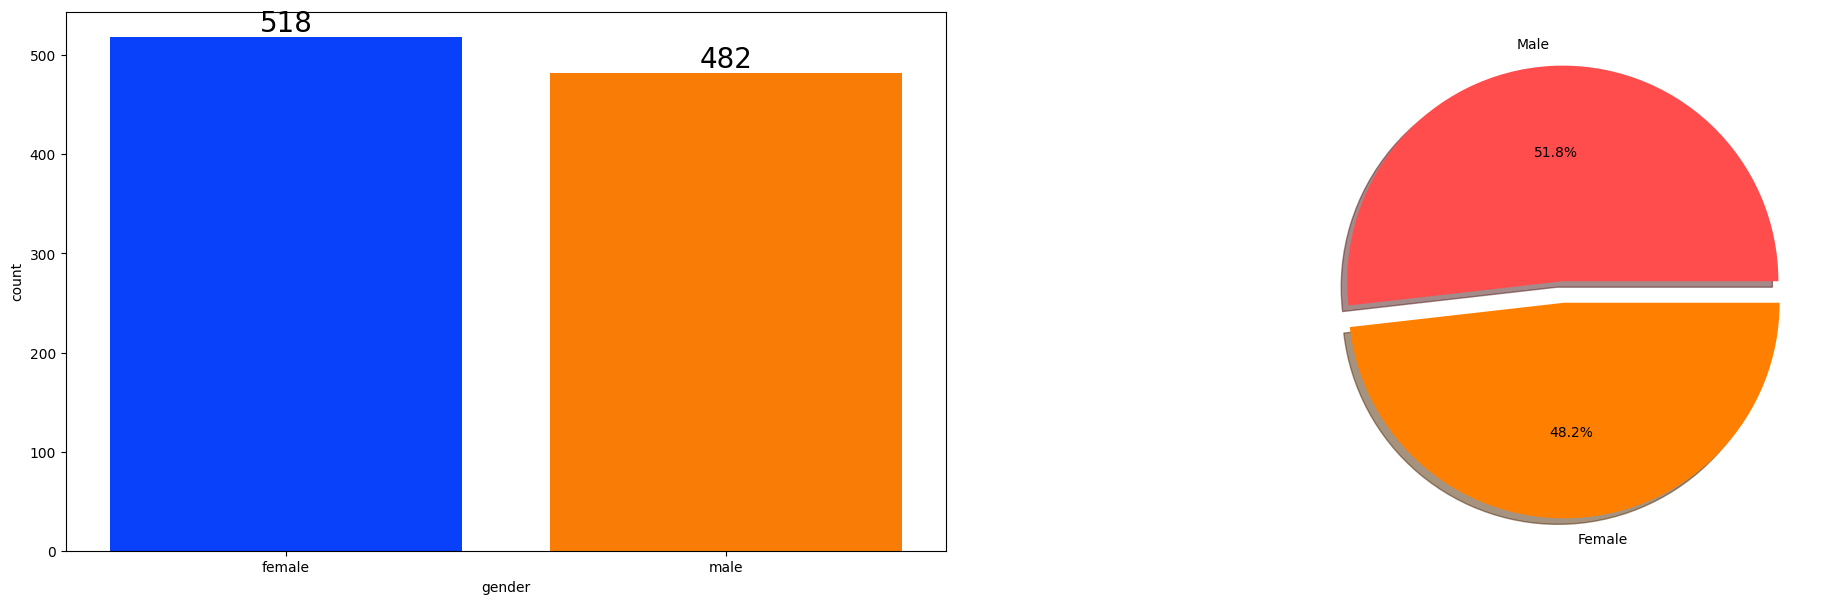

In [73]:
f,ax = plt.subplots(1,2,figsize=(25,7))
sns.countplot(x=data['gender'],data=data,palette='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)

plt.pie(x=data['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

Insights
- Gender has balanced data with female students are 518 (48%) and male students are 482 (52%)

BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? 

In [78]:
gender_groups = (
    data.groupby('gender')[['math score','reading score','writing score','average']]
    .mean()
    .round(2)
)

gender_groups

,math score,reading score,writing score,average
gender,,,,
female,63.63,72.61,72.47,69.57
male,68.73,65.47,63.31,65.84


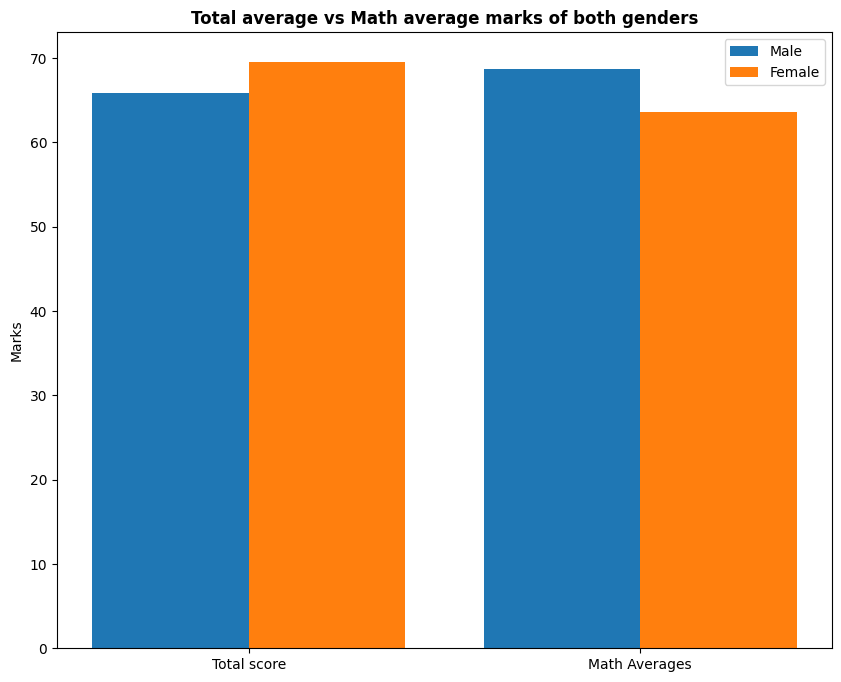

In [82]:
plt.figure(figsize=(10,8))

x =['Total score','Math Averages']

female_score=[
    gender_groups.loc['female','average'],
    gender_groups.loc['female','math score']
]

male_scores = [
    gender_groups.loc['male', 'average'],
    gender_groups.loc['male', 'math score']
]

x_axis = np.arange(len(x))

plt.bar(x_axis - 0.2,male_scores,0.4,label='Male')
plt.bar(x_axis + 0.2,female_score,0.4,label='Female')

plt.xticks(x_axis,x)
plt.ylabel("Marks")
plt.title("Total average vs Math average marks of both genders",fontweight='bold')
plt.legend()

plt.show()

Insights
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.

## 4.4.2 RACE/EHNICITY COLUMN
- How is Group wise distribution ?
- Is Race/Ehnicity has any impact on student's performance ?

# UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

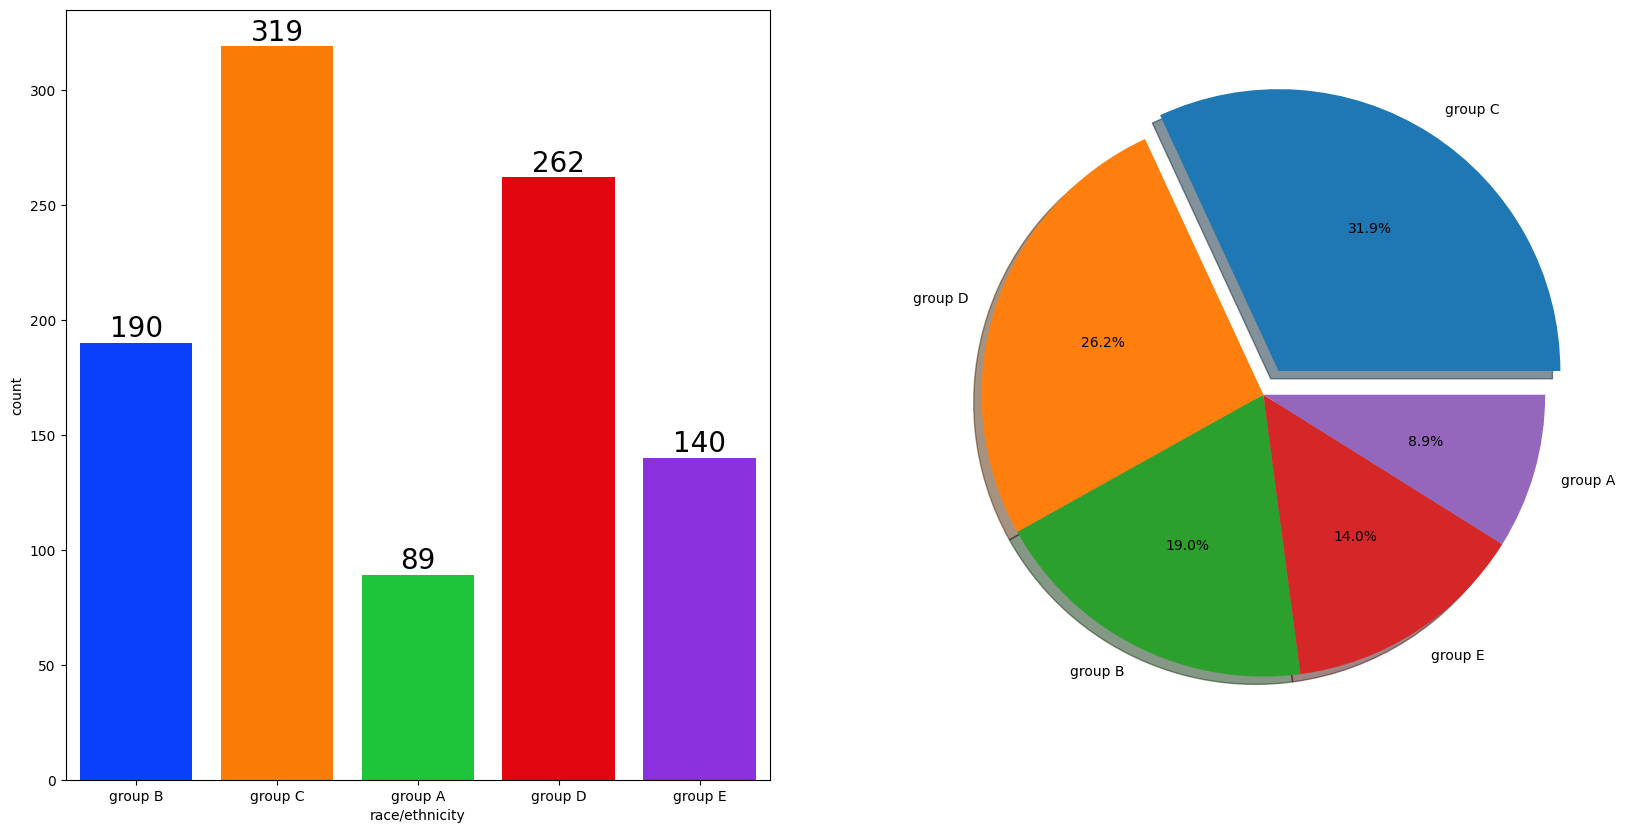

In [83]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=data['race/ethnicity'],data=data,palette = 'bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x = data['race/ethnicity'].value_counts(),labels=data['race/ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show() 

Insights
- Most of the student belonging from group C /group D.
- Lowest number of students belong to groupA.

BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

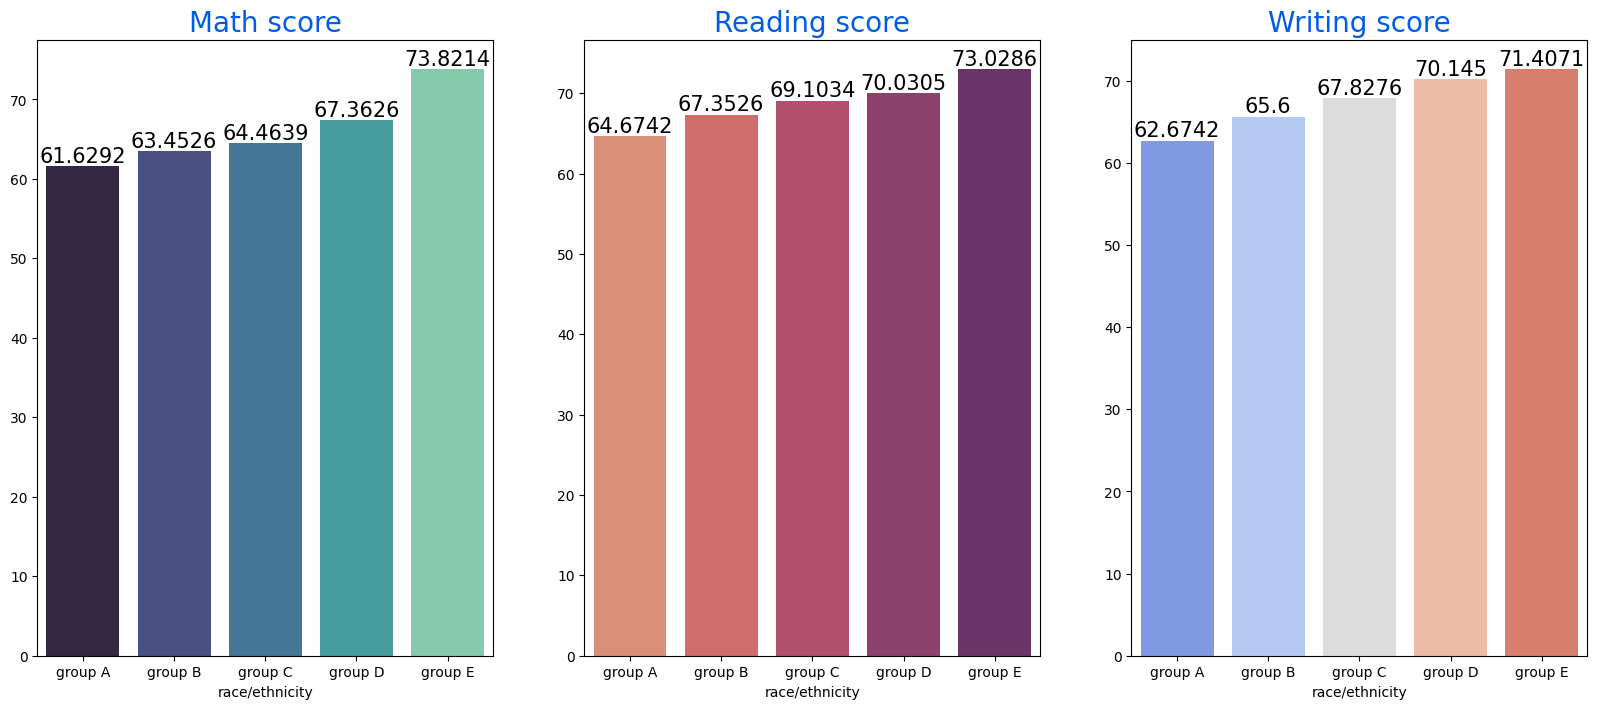

In [85]:
Group_data2=data.groupby('race/ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math score'].mean().index,y=Group_data2['math score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading score'].mean().index,y=Group_data2['reading score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing score'].mean().index,y=Group_data2['writing score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

Insights
- Group E students have scored the highest marks.
- Group A students have scored the lowest marks.
- Students from a lower Socioeconomic status have a lower avg in all course subjects


## 4.4.3 PARENTAL LEVEL OF EDUCATION COLUMN
- What is educational background of student's parent ?
- Is parental education has any impact on student's performance ?

UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

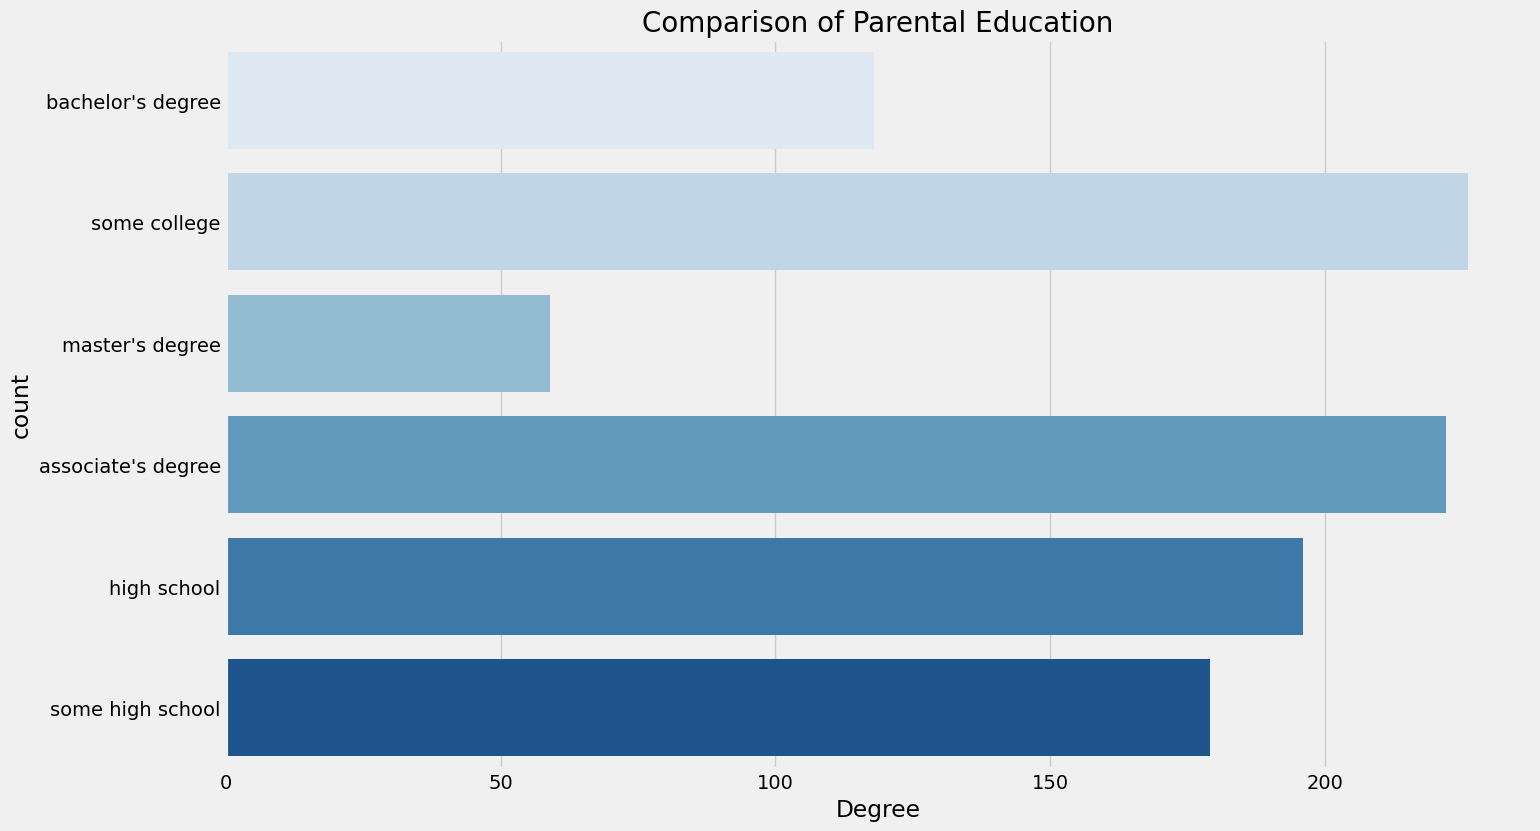

In [87]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(data['parental level of education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

Insights
- Largest number of parents are from some college.


BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

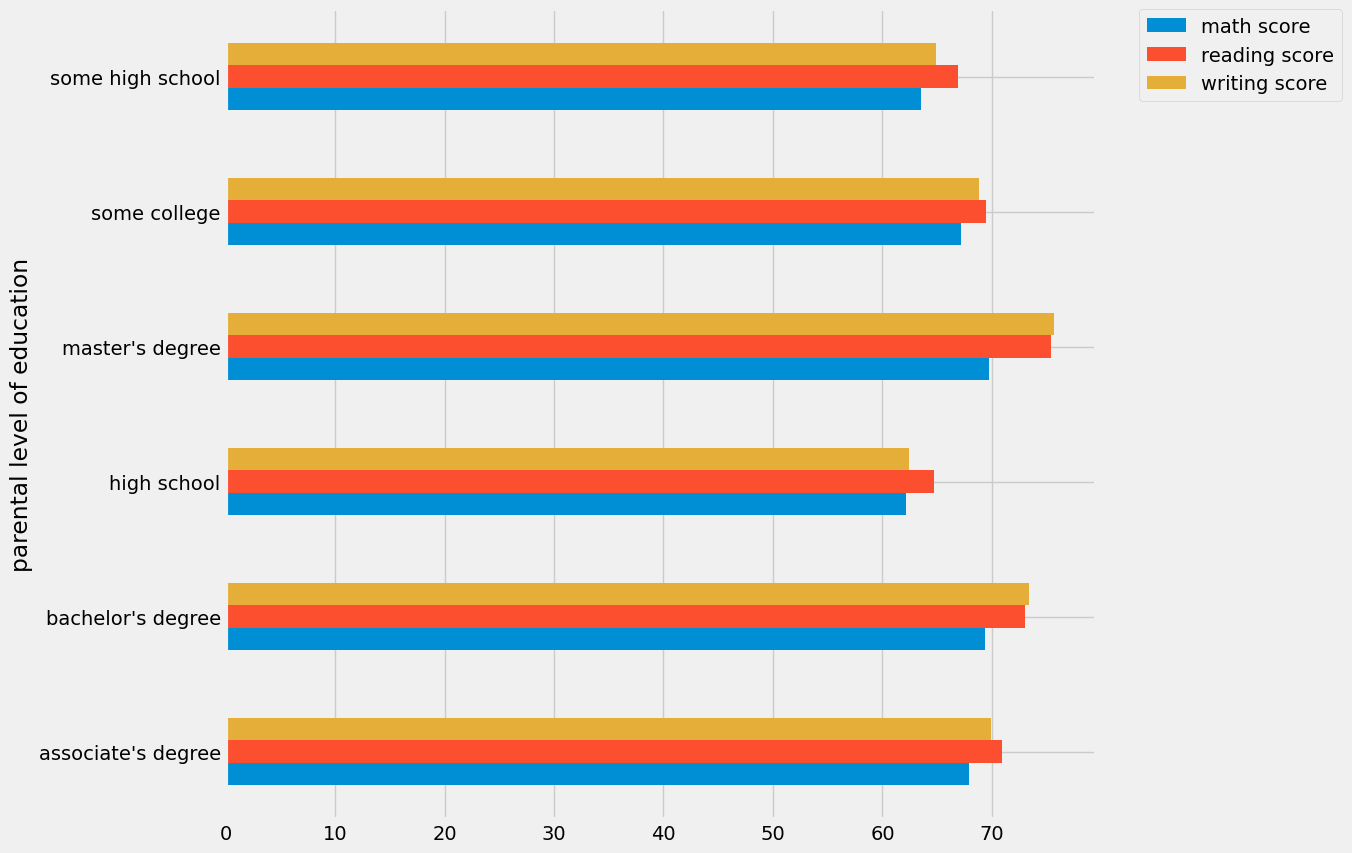

In [89]:
#data.groupby('parental level of education').agg('mean').plot(kind='barh',figsize=(10,10))
data.groupby('parental level of education')[['math score','reading score','writing score']].mean().plot(kind='barh', figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

Insights
- The score of student whose parents possess master and bachelor level education are higher than others.


## 4.4.4 LUNCH COLUMN
- Which type of lunch is most common amoung students ?
- What is the effect of lunch type on test results?


UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

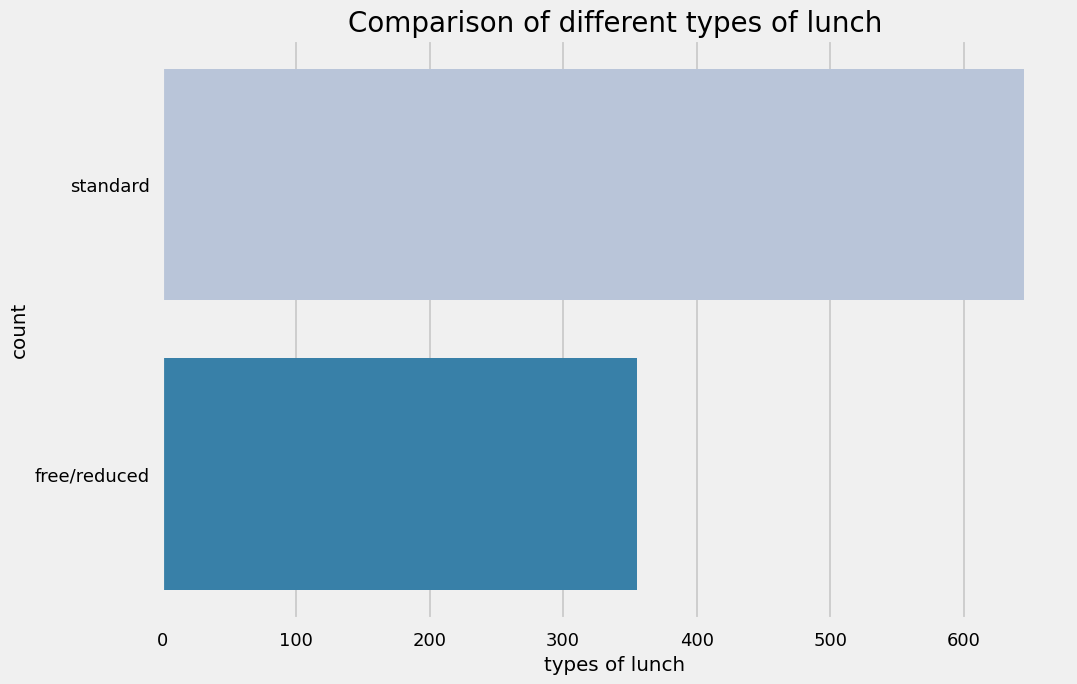

In [91]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('seaborn-v0_8-talk')
sns.countplot(data['lunch'], palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

Insights
- Students being served Standard lunch was more than free lunch


BIVARIATE ANALYSIS ( Is lunch type intake has any impact on student's performance ? )

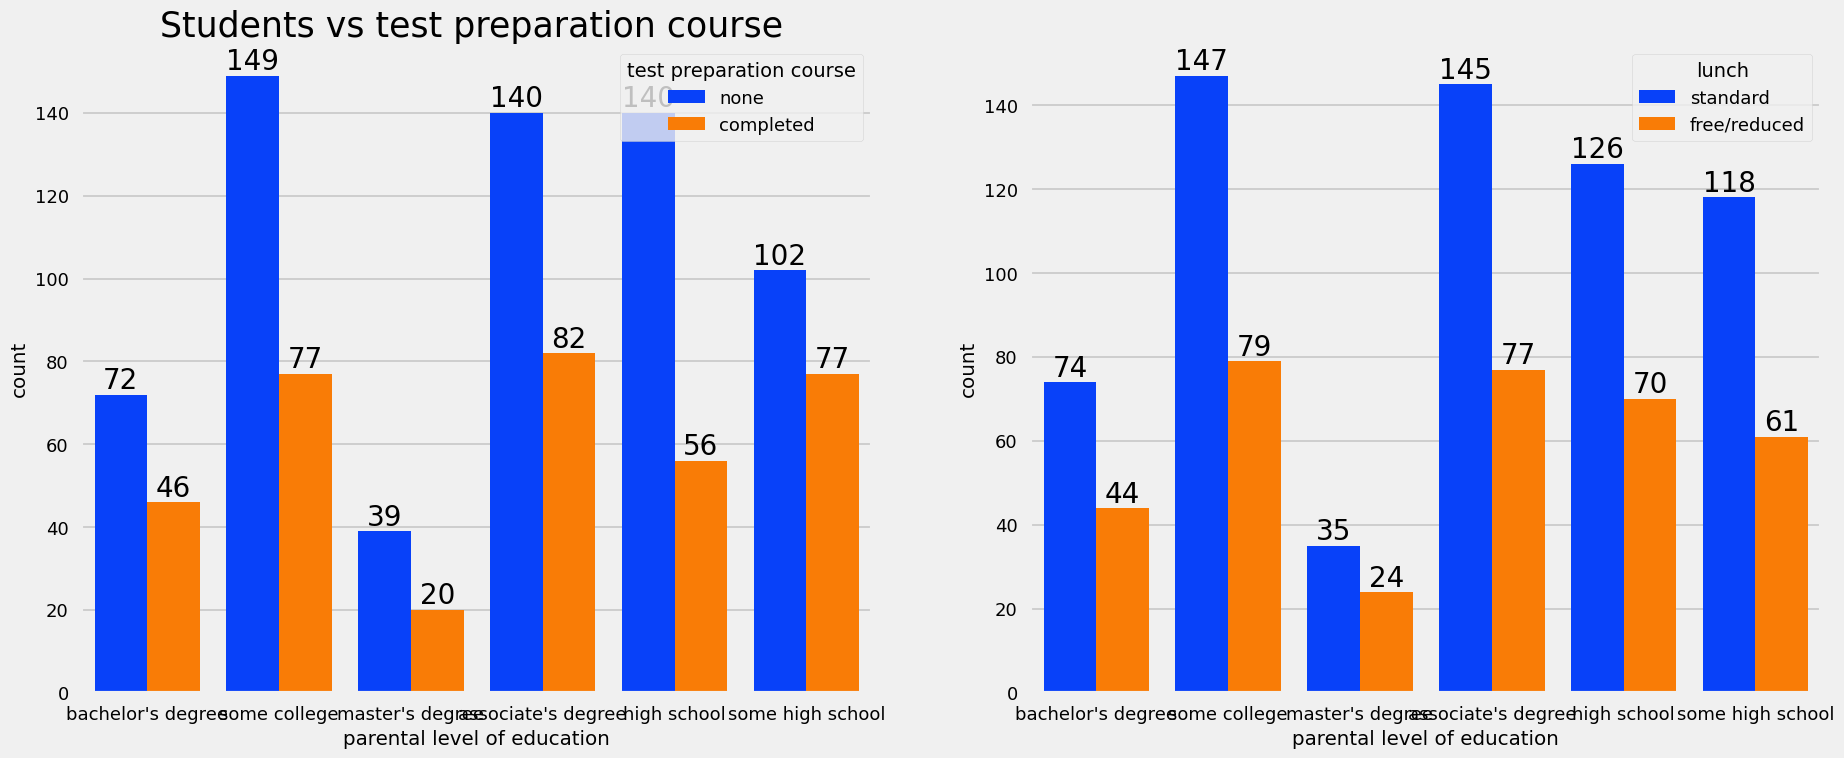

In [92]:
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.countplot(x=data['parental level of education'],data=data,palette = 'bright',hue='test preparation course',saturation=0.95,ax=ax[0])
ax[0].set_title('Students vs test preparation course ',color='black',size=25)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
sns.countplot(x=data['parental level of education'],data=data,palette = 'bright',hue='lunch',saturation=0.95,ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=20) 

Insights
- Students who get Standard Lunch tend to perform better than students who got free/reduced lunch


## 4.4.5 TEST PREPARATION COURSE COLUMN
- Which type of lunch is most common amoung students ?
- Is Test prepration course has any impact on student's performance ?


BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

<Axes: xlabel='lunch', ylabel='writing score'>

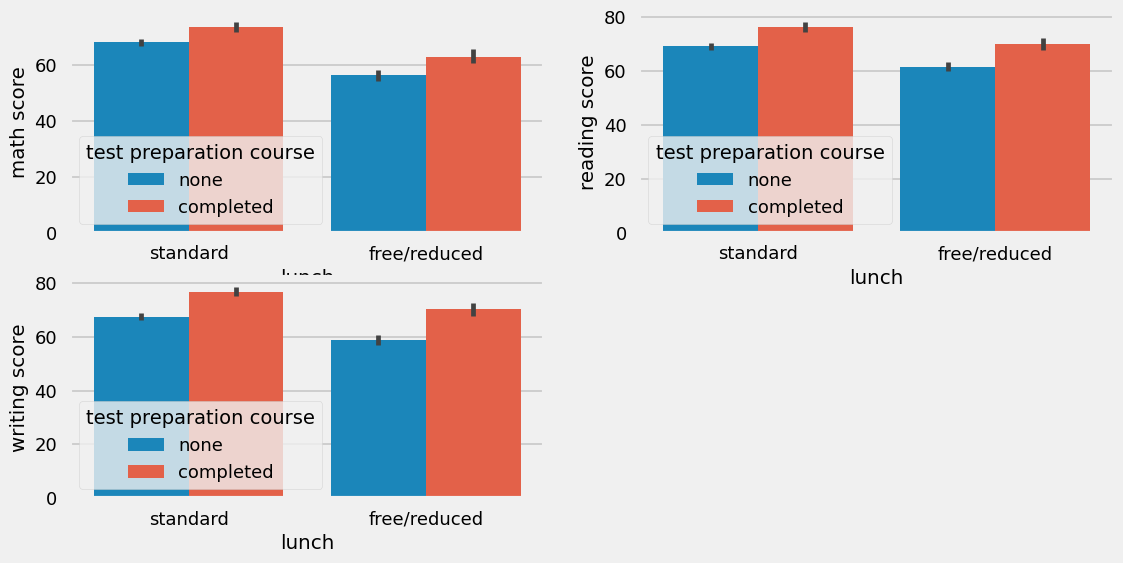

In [93]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.barplot (x=data['lunch'], y=data['math score'], hue=data['test preparation course'])
plt.subplot(2,2,2)
sns.barplot (x=data['lunch'], y=data['reading score'], hue=data['test preparation course'])
plt.subplot(2,2,3)
sns.barplot (x=data['lunch'], y=data['writing score'], hue=data['test preparation course'])

Insights
- Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course


## 4.4.6 CHECKING OUTLIERS

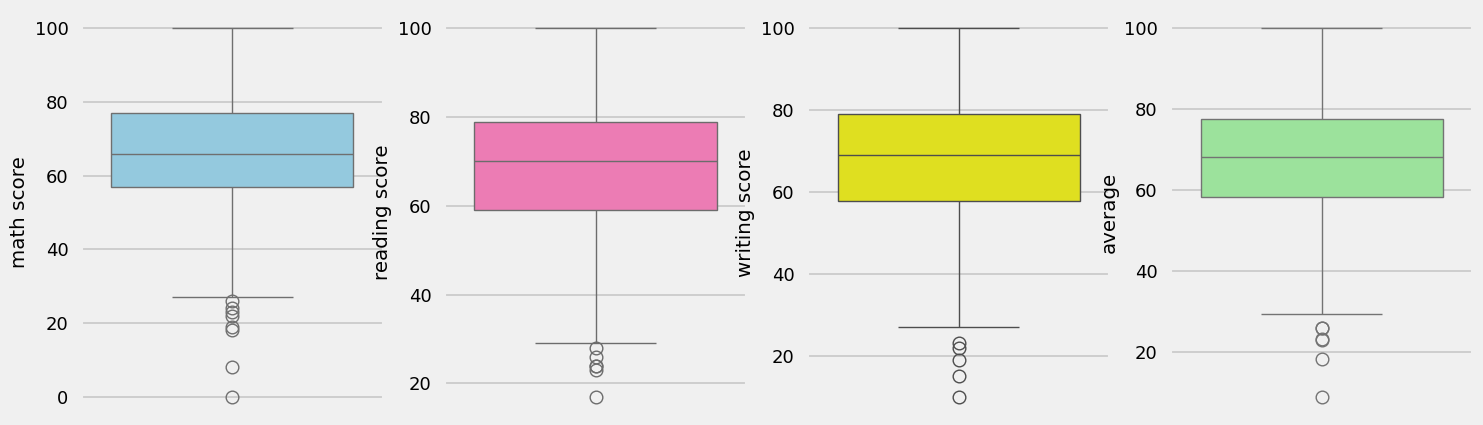

In [95]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(data['math score'],color='skyblue')
plt.subplot(142)
sns.boxplot(data['reading score'],color='hotpink')
plt.subplot(143)
sns.boxplot(data['writing score'],color='yellow')
plt.subplot(144)
sns.boxplot(data['average'],color='lightgreen')
plt.show()

## 4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

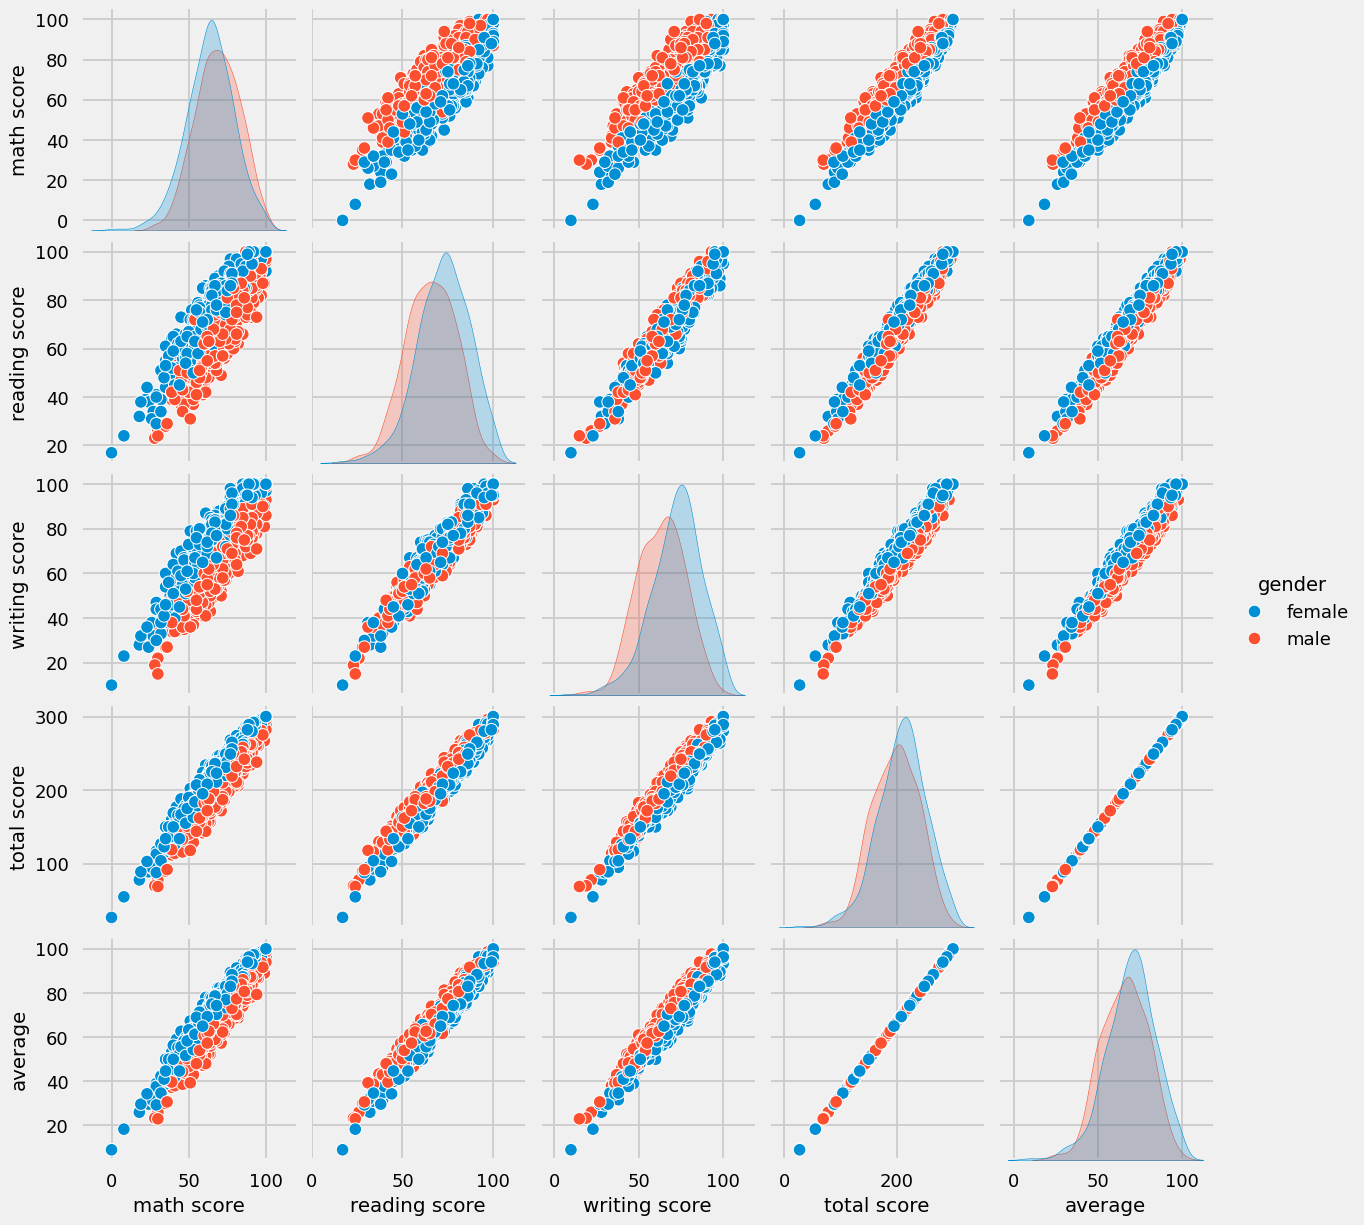

In [97]:
sns.pairplot(data,hue = 'gender')
plt.show()

Insights
- From the above plot it is clear that all the scores increase linearly with each other.


## 5. Conclusions
- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.